In [13]:
import os
import sys
import shutil
import random
import matplotlib.pyplot as plt
from collections import defaultdict
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

Number of persons: 567
Total images: 16488
Min images per person: 1
Max images per person: 78


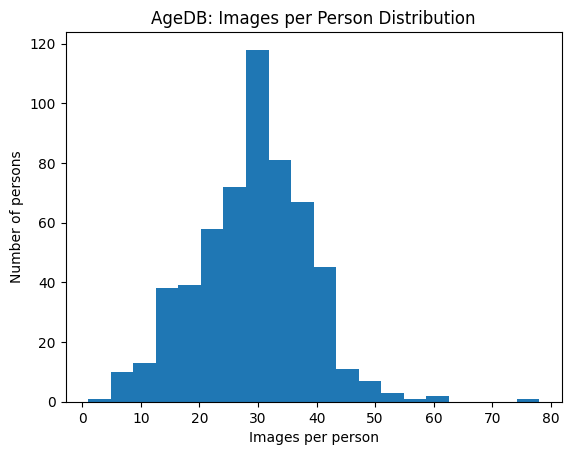

In [6]:
data_path="/kaggle/input/datasets/nathanpainchaud/agedb-dataset/AgeDB"

d=defaultdict(int)

for f in os.listdir(data_path):
    if f.lower().endswith(".jpg"):
        parts=f.replace(".jpg","").split("_")
        person="_".join(parts[1:-2])
        d[person]+=1
vals=list(d.values())

print("Number of persons:",len(d))
print("Total images:",sum(vals))
print("Min images per person:",min(vals))
print("Max images per person:",max(vals))

plt.hist(vals,bins=20)
plt.xlabel("Images per person")
plt.ylabel("Number of persons")
plt.title("AgeDB: Images per Person Distribution")
plt.show()

In [7]:
def build_triplets(path,out_dir,n=10000,max_per_person=50,age_gap=15):

    def parse(f):
        parts=f.replace(".jpg","").split("_")
        return "_".join(parts[1:-2]),int(parts[-2])

    os.makedirs(out_dir,exist_ok=True)
    data=defaultdict(list)

    for f in os.listdir(path):
        if f.lower().endswith(".jpg"):
            person,age=parse(f)
            data[person].append((f,age))

    persons=list(data.keys())
    usage=defaultdict(int)
    count=0

    while count<n:

        person=random.choice(persons)

        if usage[person]>=max_per_person:
            continue

        imgs=data[person]

        if len(imgs)<2:
            continue

        anchor=random.choice(imgs)
        positives=[x for x in imgs if abs(x[1]-anchor[1])>=age_gap]

        if not positives:
            continue

        positive=random.choice(positives)
        negative_person=random.choice([x for x in persons if x!=person])
        negative=random.choice(data[negative_person])

        folder=os.path.join(out_dir,f"triplet_{count}")
        os.makedirs(folder,exist_ok=True)

        shutil.copy(os.path.join(path,anchor[0]),os.path.join(folder,"anchor.jpg"))
        shutil.copy(os.path.join(path,positive[0]),os.path.join(folder,"positive.jpg"))
        shutil.copy(os.path.join(path,negative[0]),os.path.join(folder,"negative.jpg"))

        usage[person]+=1
        count+=1

    return f"Data saved to → {out_dir}"


build_triplets(data_path,"triplets_dataset",n=20000,max_per_person=50,age_gap=15)

'Data saved to → triplets_dataset'

In [31]:
class Siamese(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=models.resnet50(pretrained=True)
        self.backbone.fc=nn.Identity()
        self.head=nn.Sequential(
            nn.Linear(2048,1024),
            nn.ReLU(),
            nn.Linear(1024,512)
        )

    def forward(self,x):
        x=self.backbone(x)
        x=self.head(x)
        x=F.normalize(x,p=2,dim=1)
        return x

class TripletDataset(Dataset):
    def __init__(self, root, transform=None, split="train", ratio=0.8, seed=42):
        self.root = root
        self.t = transform
        self.data = sorted(os.listdir(root))
        random.seed(seed)
        random.shuffle(self.data)
        cut = int(len(self.data) * ratio)

        if split == "train":
            self.data = self.data[:cut]
        else:
            self.data = self.data[cut:]

    def __len__(self):
        return len(self.data)

    def _load_img(self, path):
        return Image.open(path).convert("RGB")

    def __getitem__(self, i):
        folder = os.path.join(self.root, self.data[i])
        a = self._load_img(os.path.join(folder, "anchor.jpg"))
        p = self._load_img(os.path.join(folder, "positive.jpg"))
        n = self._load_img(os.path.join(folder, "negative.jpg"))
        if self.t:
            a = self.t(a)
            p = self.t(p)
            n = self.t(n)

        return a, p, n

In [32]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


train_ds=TripletDataset("/kaggle/working/triplets_dataset",transform,split="train")
val_ds=TripletDataset("/kaggle/working/triplets_dataset",transform,split="val")

train_loader=DataLoader(train_ds,batch_size=32,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=32,shuffle=False)

In [33]:
def dist(a,b):
    return 1 - torch.nn.functional.cosine_similarity(a,b)

loss_fn=nn.TripletMarginLoss(margin=1)

device="cuda" if torch.cuda.is_available() else "cpu"

model=Siamese().to(device)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
Siamese                                       [1, 512]                  --
├─ResNet: 1-1                                 [1, 2048]                 --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [1, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [1, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 28, 28]          379,392

In [34]:
for name, param in model.backbone.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer=optim.Adam(filter(lambda a: a.requires_grad, model.parameters()),lr=1e-4)

In [35]:
def train(model,train_loader,val_loader,epochs,device):
    best_acc = 0
    for epoch in range(epochs):
        model.train()
        tl=tc=tt=0
        for i,(a,p,n) in enumerate(train_loader):
            a,p,n=a.to(device),p.to(device),n.to(device)
            ea,ep,en=model(a),model(p),model(n)
            loss=loss_fn(ea,ep,en)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tl+=loss.item()
            tc+=(dist(ea,ep)<dist(ea,en)).sum().item()
            tt+=a.size(0)
            sys.stdout.write(
                f"\rEpoch {epoch+1}/{epochs} | Batch {i+1}/{len(train_loader)} | " f"Train Loss {tl/(i+1):.4f} | Train Acc {tc/tt:.4f}")
            sys.stdout.flush()
        print()

        model.eval()
        vl=vc=vt=0
        with torch.no_grad():
            for a,p,n in val_loader:
                a,p,n=a.to(device),p.to(device),n.to(device)
                ea,ep,en=model(a),model(p),model(n)
                loss=loss_fn(ea,ep,en)
                vl+=loss.item()
                vc+=(dist(ea,ep)<dist(ea,en)).sum().item()
                vt+=a.size(0)

        print(f"Epoch {epoch+1} | "f"Val Loss {vl/len(val_loader):.4f} | " f"Val Acc {vc/vt:.4f}")

        val_acc = vc/vt
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_encoder.pth")

In [36]:
train(model,train_loader,val_loader,epochs=10,device=device)

Epoch 1/10 | Batch 500/500 | Train Loss 0.5224 | Train Acc 0.7850
Epoch 1 | Val Loss 0.4433 | Val Acc 0.8240
Epoch 2/10 | Batch 500/500 | Train Loss 0.3890 | Train Acc 0.8519
Epoch 2 | Val Loss 0.3978 | Val Acc 0.8442
Epoch 3/10 | Batch 500/500 | Train Loss 0.3219 | Train Acc 0.8903
Epoch 3 | Val Loss 0.3851 | Val Acc 0.8505
Epoch 4/10 | Batch 500/500 | Train Loss 0.2725 | Train Acc 0.9157
Epoch 4 | Val Loss 0.3678 | Val Acc 0.8650
Epoch 5/10 | Batch 500/500 | Train Loss 0.2478 | Train Acc 0.9293
Epoch 5 | Val Loss 0.3601 | Val Acc 0.8692
Epoch 6/10 | Batch 500/500 | Train Loss 0.2150 | Train Acc 0.9404
Epoch 6 | Val Loss 0.3461 | Val Acc 0.8712
Epoch 7/10 | Batch 500/500 | Train Loss 0.1969 | Train Acc 0.9521
Epoch 7 | Val Loss 0.3357 | Val Acc 0.8745
Epoch 8/10 | Batch 500/500 | Train Loss 0.1810 | Train Acc 0.9566
Epoch 8 | Val Loss 0.3379 | Val Acc 0.8738
Epoch 9/10 | Batch 500/500 | Train Loss 0.1735 | Train Acc 0.9617
Epoch 9 | Val Loss 0.3424 | Val Acc 0.8698
Epoch 10/10 | Batch

The final weights are available here [Best weights on Kaggle](https://www.kaggle.com/datasets/mhmdelshoraky/best-encoder-model)

The deployed application vailable here [Reunite](https://reunitee.pages.dev/)